In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare, kstest

In [56]:
# Linear congruential generator
class LCG:
    def __init__(self, a: int, c: int, M: int, start: int = 0) -> None:
        self.a = a
        self.c = c
        self.M = M
        self.x_curr = start

    def next(self) -> int:
        self.x_curr = (self.a * self.x_curr + self.c) % self.M
        return self.x_curr

In [57]:
n: int = 10000
num_classes: int = 10


def run_test(start: int):
    classes = np.zeros(num_classes, dtype=int)
    numbers = np.zeros(n)

    lcg = LCG(a, c, M, start)

    for i in range(n):
        numbers[i] = lcg.next()/M
        class_i = int(numbers[i]*10)
        classes[class_i] += 1

    return classes, numbers

a, c, M = 65, 1, 2**8
classes, numbers_bad = run_test(324)

a, c, M = 16387, 1, 2**31
classes, numbers_good = run_test(324)

numbers = numbers_good


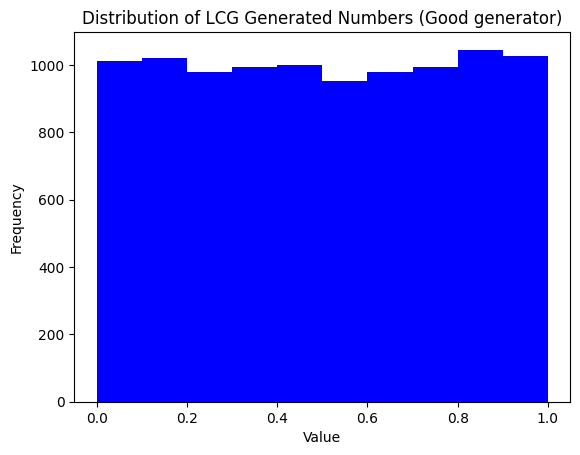

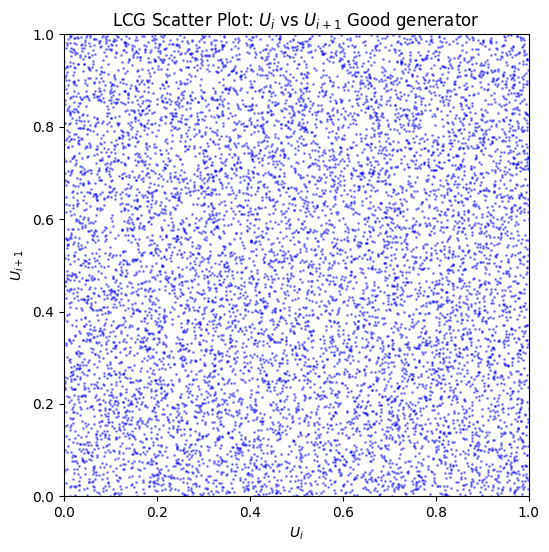

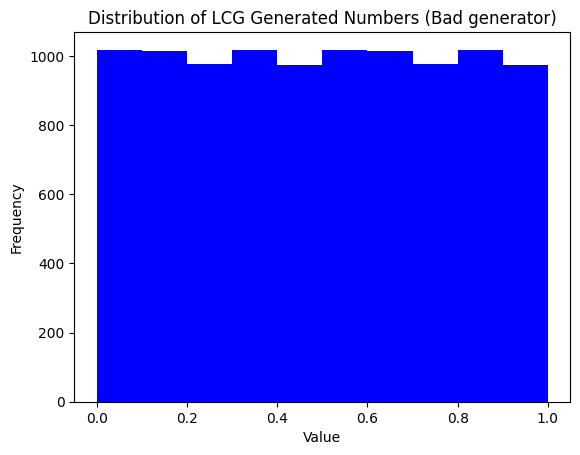

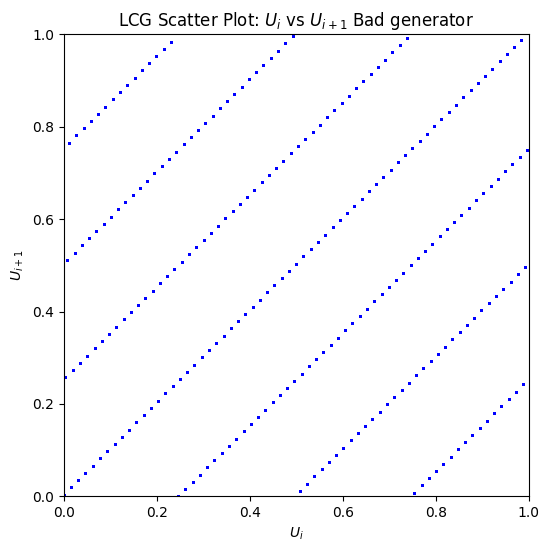

In [58]:
def plot(numbers, num_classes, title):
    # Histogram
    x_labels = np.arange(num_classes)

    plt.hist(numbers, bins=10, range=(0,1), color='blue')
    plt.title(f"Distribution of LCG Generated Numbers ({title} generator)")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

    # Scatter
    x_coords = numbers[:-1] # all without the last one
    y_coords = numbers[1:] # all shifted by one position

    plt.figure(figsize=(6, 6))

    plt.scatter(x_coords, y_coords, s=1, alpha=0.4, color='blue')

    str = "LCG Scatter Plot: $U_i$ vs $U_{i+1}$ " + title + " generator"

    plt.title(str)
    plt.xlabel("$U_i$")
    plt.ylabel("$U_{i+1}$")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.show()

plot(numbers_good, num_classes, "Good")
plot(numbers_bad, num_classes, "Bad")

In [59]:
# chi squared test
expected_freq = n / num_classes
chi_sq, p_value = chisquare(f_obs=classes, f_exp=expected_freq)

print("Chi Squared test:")
print(f"X^2: {chi_sq}, p: {p_value}")

print()

# kolmogorov test
d_statistic, p_value = kstest(numbers, 'uniform')
print("Kolmogorov test:")
print(f"D: {d_statistic}, p: {p_value}")

# I tried also by not using the built in functions but the TAs said It's useful to compute the p value
# which I didn't know how to do from scratch...

Chi Squared test:
X^2: 6.468000000000001, p: 0.6923176772060882

Kolmogorov test:
D: 0.009470972544699863, p: 0.3290091412957967


In [61]:
def wald_wolfowitz_test(data):
    n = len(data)
    median = 0.5
    runs = [1 if x > median else -1 for x in data]
    
    r = 1
    for i in range(1, n):
        if runs[i] != runs[i-1]:
            r += 1
            
    n1 = runs.count(1)
    n2 = runs.count(-1)
    
    expected_r = (2 * n1 * n2) / (n1 + n2) + 1
    variance_r = (2 * n1 * n2 * (2 * n1 * n2 - n1 - n2)) / ((n1 + n2)**2 * (n1 + n2 - 1))
    
    z = (r - expected_r) / (variance_r**0.5)
    return z 

print("Wald Wolfowitz test:")
print(f"z: {wald_wolfowitz_test(numbers)}")

Wald Wolfowitz test:
z: -0.5399911973418035


In [62]:
def up_down_test(data):
    n = len(data)
    comparisons = [1 if data[i+1] > data[i] else -1 for i in range(n-1)]
    
    runs = 1
    for i in range(1, len(comparisons)):
        if comparisons[i] != comparisons[i-1]:
            runs += 1
            
    z = (runs - ((2*n - 1) / 3)) / (((16*n - 29) / 90)**0.5)
    return z

print("Up Down test:")
print(f"z: {up_down_test(numbers)}")

Up Down test:
z: -1.265025712217744


In [63]:
def knuth_run_length_test(data):
    run_lengths = []
    current_len = 1
    for i in range(len(data) - 1):
        if data[i+1] > data[i]:
            current_len += 1
        else:
            run_lengths.append(min(current_len, 6))
            current_len = 1

    run_lengths.append(min(current_len, 6))

    R = np.zeros(6)
    for x in run_lengths:
        R[x - 1] += 1

    A = np.array([
        [4529.4, 9044.9, 13568, 18091, 22615, 27892],
        [9044.9, 18097, 27139, 36187, 45234, 55789],
        [13568, 27139, 40721, 54281, 67852, 83685],
        [18091, 36187, 54281, 72414, 90470, 111580],
        [22615, 45234, 67852, 90470, 113262, 139476],
        [27892, 55789, 83685, 111580, 139476, 172860]
    ])
    
    B = np.array([1/6, 5/24, 11/120, 19/720, 29/5040, 1/840])

    diff = R - (n * B)
    z_stat = (1 / (n - 6)) * np.dot(diff.T, np.dot(A, diff))

    return z_stat

print("Knuth length test:")
print(f"z: {knuth_run_length_test(numbers)}")

Knuth length test:
z: 6.54771058150122


In [64]:
def lagged_correlation_test(data, h):
    ch = np.sum(data[:n-h] * data[h:]) / (n - h)
    
    expected = 0.25
    variance = 7 / (144 * n)
    std_dev = np.sqrt(variance)
    
    z = (ch - expected) / std_dev
    
    return ch, z

print("Lagged Correlation Test:")
for h in range(1, 6):
    ch, z = lagged_correlation_test(numbers, h)
    print(f"Lag {h}: Ch = {ch}, Z = {z}")

Lagged Correlation Test:
Lag 1: Ch = 0.25108005259056904, Z = 0.48986580986001166
Lag 2: Ch = 0.2509802692481584, Z = 0.44460833974481667
Lag 3: Ch = 0.25168683620776594, Z = 0.7650769899853644
Lag 4: Ch = 0.2523793860293462, Z = 1.0791880640008138
Lag 5: Ch = 0.2506818915213352, Z = 0.30927692341309715


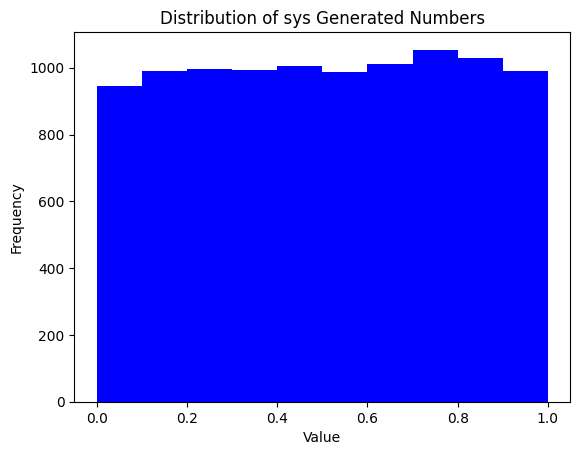

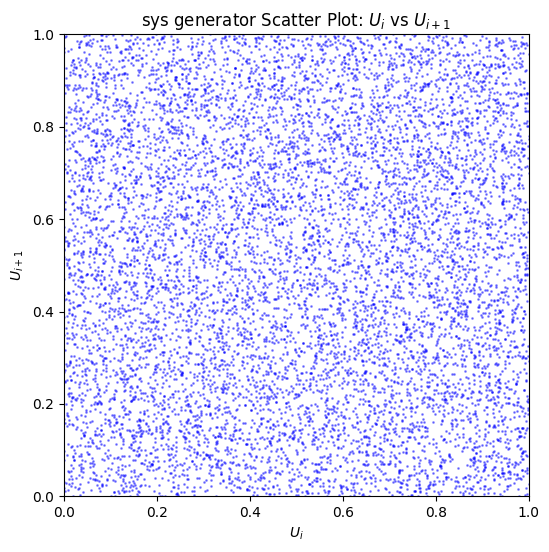

Chi Squared:    X^2=7.312, p=0.6046708287899327
Kolmogorov:     D=0.009998618623642597, p=0.2683665278064292
Wald-Wolfowitz: z=0.22021941961194663
Up-Down:        z=-0.98039492696875
Knuth:          χ^2=3.4876755128407027
Lag 1: Ch=0.25494966093431043, Z=2.2449551839332007
Lag 2: Ch=0.25419033238462824, Z=1.900556125787412
Lag 3: Ch=0.2545541666255985, Z=2.0655758263686517
Lag 4: Ch=0.2557642934488465, Z=2.614437762796566
Lag 5: Ch=0.25522181693443213, Z=2.3683935429279597


In [65]:
# Part 2

# I used numpy random uniform generator

system_numbers = np.random.uniform(size=n)

plt.hist(system_numbers, bins=10, range=(0,1), color='blue')
plt.title("Distribution of sys Generated Numbers")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(system_numbers[:-1], system_numbers[1:], s=1, alpha=0.4, color='blue')
plt.title("sys generator Scatter Plot: $U_i$ vs $U_{i+1}$")
plt.xlabel("$U_i$"); plt.ylabel("$U_{i+1}$")
plt.xlim(0,1); plt.ylim(0,1)
plt.show()

chi_sq, p_value = chisquare(f_obs=np.histogram(system_numbers, bins=10, range=(0,1))[0], f_exp=n/10)
print(f"Chi Squared:    X^2={chi_sq}, p={p_value}")
d_statistic, p_value = kstest(system_numbers, 'uniform')
print(f"Kolmogorov:     D={d_statistic}, p={p_value}")
print(f"Wald-Wolfowitz: z={wald_wolfowitz_test(system_numbers)}")
print(f"Up-Down:        z={up_down_test(system_numbers)}")
print(f"Knuth:          χ^2={knuth_run_length_test(system_numbers)}")
for h in range(1, 6):
    ch, z = lagged_correlation_test(system_numbers, h)
    print(f"Lag {h}: Ch={ch}, Z={z}")

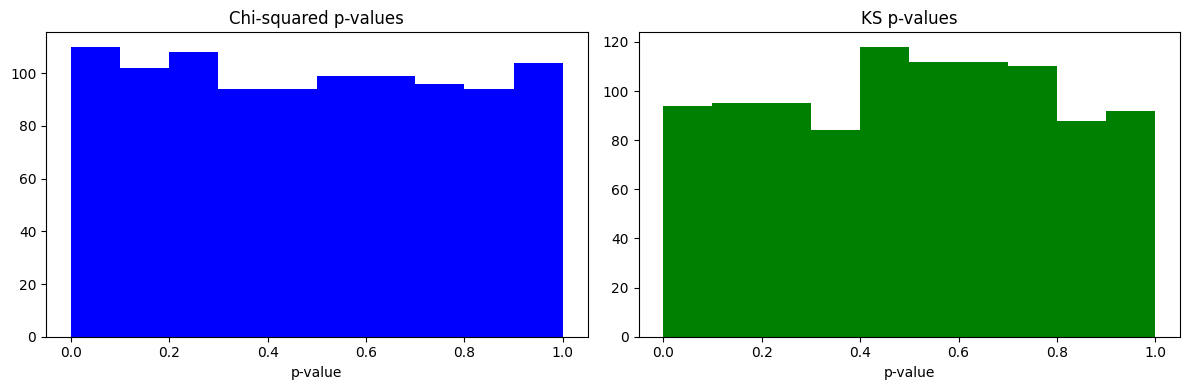

In [66]:
# Part 3
 
# One sample containing 10000 numbers is not sufficient to make strong conclusions.
# I performed the test 1000 times using
# different start numbers to verify that the p-values are uniformly distributed from 0 to 1.

chi_pvals, ks_pvals = [], []
for start_n in range(1000):
    _, nums = run_test(start_n * 1000 + 1)
    _, cp = chisquare(f_obs=np.histogram(nums, bins=10, range=(0,1))[0], f_exp=n/10)
    d, kp = kstest(nums, 'uniform')
    chi_pvals.append(cp)
    ks_pvals.append(kp)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(chi_pvals, bins=10, range=(0,1), color='blue')
plt.title("Chi-squared p-values")
plt.xlabel("p-value")
plt.subplot(1, 2, 2)
plt.hist(ks_pvals, bins=10, range=(0,1), color='green')
plt.title("KS p-values")
plt.xlabel("p-value")
plt.tight_layout()
plt.show()

# Initially I performed 100 iterations where some minor irregularities could be
# observed, including a small peak around 0.2-0.3 when using chi-square. With 100
# runs involved it is normal since these are just random deviations.
# When repeating the procedure with 1000 start numbers we get a smoother graph,
# proving that there are no problems with the generator and those deviations
# occurred because of the low number of runs.